#**Retail Store Sales Analysis and Prediction**

##**Introduction**
The Retail Store Sales Prediction project was developed to analyze customer transaction data and predict customer spending behavior using machine learning techniques. Retail businesses generate large amounts of transactional data every day, and analyzing this data can help organizations improve decision-making, sales strategies, inventory planning, and customer understanding.

This project focuses on the complete data science workflow, including data loading, data cleaning, exploratory data analysis (EDA), feature engineering, predictive modeling, model optimization, and visualization. The dataset contains retail transaction information such as product category, item type, quantity purchased, payment method, location, discount status, and total spending amount.

Machine learning models such as Linear Regression and Ridge Regression were used to predict the Total Spent value. Different visualizations and evaluation metrics were also applied to understand customer purchasing patterns and evaluate model performance.

Overall, this project demonstrates how data analytics and machine learning can be applied in the retail industry to support business intelligence and improve sales prediction accuracy.

##**Project Objectives**
The main objectives of this project are:
1.   To load and preprocess retail transaction
data for analysis and machine learning.
2.   To identify and handle missing values, inconsistent data, and duplicate records.
3. To perform Exploratory Data Analysis (EDA) using different visualizations to understand customer purchasing behavior and sales trends.
4. To create new features that improve the predictive performance of machine learning models.
5. To build predictive models that can estimate customer Total Spent values.
6. To evaluate machine learning models using regression metrics such as MAE, MSE, RMSE, and R-squared.
7. To optimize model performance using hyperparameter tuning and dimensionality reduction techniques.
8. To generate business insights that can help improve retail sales strategies and customer understanding.





##**Problem Statement**

Retail businesses generate large amounts of transaction data every day, but it is difficult to accurately predict customer spending behavior and sales patterns. Without proper analysis, businesses may face challenges in inventory management, sales forecasting, and understanding customer purchasing trends.

This project aims to analyze retail transaction data and use machine learning techniques to predict customer Total Spent values. The project also focuses on identifying important sales trends and customer behavior patterns that can support better business decision-making.

##Import Libraries and Dataset Loading





In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Make plots look clean
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [2]:
# Load the dataset
df = pd.read_csv('https://raw.githubusercontent.com/maybraniswe/Retail-Store-Sales-Analysis-and-Prediction/refs/heads/main/retail_store_sales.csv')

# Check dataset size
df.shape

(12575, 11)

Observation:

The dataset is successfully loaded into a pandas DataFrame.
The dataset contains 12,575 rows and 11 columns.
Each row represents one retail transaction record.

##Initial Data Inspection

In [3]:
# Display first 5 rows
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


Observation:

The first few records show transaction details including Transaction ID, Customer ID, Category, Item, Price Per Unit, Quantity, Total Spent, Payment Method, Location, Transaction Date, and Discount Applied.

In [4]:
# Display statistical summary for numerical columns
df.describe().round(2)

,Price Per Unit,Quantity,Total Spent
count,11966.00,11971.00,11971.00
mean,23.37,5.54,129.65
std,10.74,2.86,94.75
min,5.00,1.00,5.00
25%,14.00,3.00,51.00
50%,23.00,6.00,108.50
75%,33.50,8.00,192.00
max,41.00,10.00,410.00


Observation:

Price Per Unit ranges from 5.00 to 41.00.
Quantity ranges from 1 to 10.
Total Spent ranges from 5.00 to 410.00.
This shows that the numerical values are within a reasonable range.

In [5]:
# Display full data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


Observation:

The dataset has both object and numeric data types.
Transaction Date is currently stored as object, so it needs to be converted to datetime.
Discount Applied is also stored as object and should be converted to boolean/category.

In [6]:
# Check missing values
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,1213
Price Per Unit,609
Quantity,604
Total Spent,604
Payment Method,0
Location,0
Transaction Date,0


Observation:

Missing values are found in Item, Price Per Unit, Quantity, Total Spent, and Discount Applied.
These missing values need to be handled before analysis and modeling.

##Data Cleaning


In [7]:
# ==========================================================
# DATA CLEANING
# ==========================================================

# Create a copy of original dataset
clean_df = df.copy()

# Check original shape
print("Original dataset shape:", clean_df.shape)

Original dataset shape: (12575, 11)


Observation:

A copy is created so the original dataset remains unchanged.
This is a good practice before performing data cleaning.

In [8]:
# ==========================================================
# REMOVE DUPLICATE ROWS
# ==========================================================

duplicate_count = clean_df.duplicated().sum()
print("Duplicate rows before cleaning:", duplicate_count)

clean_df = clean_df.drop_duplicates()

print("Duplicate rows after cleaning:", clean_df.duplicated().sum())
print("Dataset shape after removing duplicates:", clean_df.shape)

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0
Dataset shape after removing duplicates: (12575, 11)


Observation:

Fully duplicate rows are checked and removed.
This helps avoid repeated records affecting the analysis.

In [9]:
# ==========================================================
# CONVERT TRANSACTION DATE TO DATETIME
# ==========================================================

clean_df["Transaction Date"] = pd.to_datetime(
    clean_df["Transaction Date"],
    errors="coerce"
)

clean_df["Transaction Date"].dtype

dtype('<M8[ns]')

Observation:

Transaction Date is converted from object to datetime format.
This allows future analysis by year, month, or day.

In [10]:
# ==========================================================
# STANDARDIZE CATEGORICAL TEXT COLUMNS
# ==========================================================

categorical_cols = [
    "Transaction ID",
    "Customer ID",
    "Category",
    "Item",
    "Payment Method",
    "Location",
    "Discount Applied"
]

for col in categorical_cols:
    clean_df[col] = clean_df[col].astype(str).str.strip().str.lower()

 # Convert fake string missing values back to real NaN
clean_df = clean_df.replace(
    ["nan", "none", ""],
    np.nan
)
clean_df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,txn_6867343,cust_09,patisserie,item_10_pat,18.5,10.0,185.0,digital wallet,online,2024-04-08,true
1,txn_3731986,cust_22,milk products,item_17_milk,29.0,9.0,261.0,digital wallet,online,2023-07-23,true
2,txn_9303719,cust_02,butchers,item_12_but,21.5,2.0,43.0,credit card,online,2022-10-05,false
3,txn_9458126,cust_06,beverages,item_16_bev,27.5,9.0,247.5,credit card,online,2022-05-07,NaN
4,txn_4575373,cust_05,food,item_6_food,12.5,7.0,87.5,digital wallet,online,2022-10-02,false



Observation:

Extra spaces are removed from categorical columns.
This helps avoid inconsistent values such as 'Cash ' and 'Cash' being treated as different categories.

In [11]:
# ==========================================================
# HANDLE MISSING VALUES
# ==========================================================

# Remove rows where both Item and Price Per Unit are missing
clean_df = clean_df.dropna(
    subset=["Item", "Price Per Unit"],
    how="all"
)

# Create reference table from available Item and Price Per Unit
item_price_table = clean_df[["Item", "Price Per Unit"]].dropna().drop_duplicates()

# Fill missing Item using Price Per Unit
price_to_item = item_price_table.drop_duplicates("Price Per Unit") \
                                .set_index("Price Per Unit")["Item"]

clean_df["Item"] = clean_df["Item"].fillna(
    clean_df["Price Per Unit"].map(price_to_item)
)

# Fill missing Price Per Unit using Item
item_to_price = item_price_table.drop_duplicates("Item") \
                                .set_index("Item")["Price Per Unit"]

clean_df["Price Per Unit"] = clean_df["Price Per Unit"].fillna(
    clean_df["Item"].map(item_to_price)
)

# Fill Quantity using median
clean_df["Quantity"] = clean_df["Quantity"].fillna(
    clean_df["Quantity"].median()
)

# Recalculate Total Spent
clean_df["Total Spent"] = clean_df["Price Per Unit"] * clean_df["Quantity"]

# Fill Discount Applied
clean_df["Discount Applied"] = (
    clean_df["Discount Applied"]
    .map({"true": True, "false": False})
    .fillna(False)
    .astype(bool)
)

clean_df.isnull().sum()

/tmp/ipykernel_2253/395765695.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)


,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


Observation:

Missing values were handled using different strategies based on the column type.

Item and Price Per Unit were filled using their relationship.

Quantity was filled using the median value.

Total Spent was recalculated to maintain accuracy.

Discount Applied missing values were filled as False.

In [12]:
# ==========================================================
# FINAL CLEAN DATA CHECK
# ==========================================================

print("Final dataset shape:", clean_df.shape)

print("\nFinal missing values:")
print(clean_df.isnull().sum())

print("\nFinal data types:")
print(clean_df.dtypes)

clean_df.head()

Final dataset shape: (11966, 11)

Final missing values:
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

Final data types:
Transaction ID              object
Customer ID                 object
Category                    object
Item                        object
Price Per Unit             float64
Quantity                   float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
Discount Applied              bool
dtype: object


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,txn_6867343,cust_09,patisserie,item_10_pat,18.5,10.0,185.0,digital wallet,online,2024-04-08,True
1,txn_3731986,cust_22,milk products,item_17_milk,29.0,9.0,261.0,digital wallet,online,2023-07-23,True
2,txn_9303719,cust_02,butchers,item_12_but,21.5,2.0,43.0,credit card,online,2022-10-05,False
3,txn_9458126,cust_06,beverages,item_16_bev,27.5,9.0,247.5,credit card,online,2022-05-07,False
4,txn_4575373,cust_05,food,item_6_food,12.5,7.0,87.5,digital wallet,online,2022-10-02,False


##Exploratory Data Analysis (EDA)

####Univariate Analysis

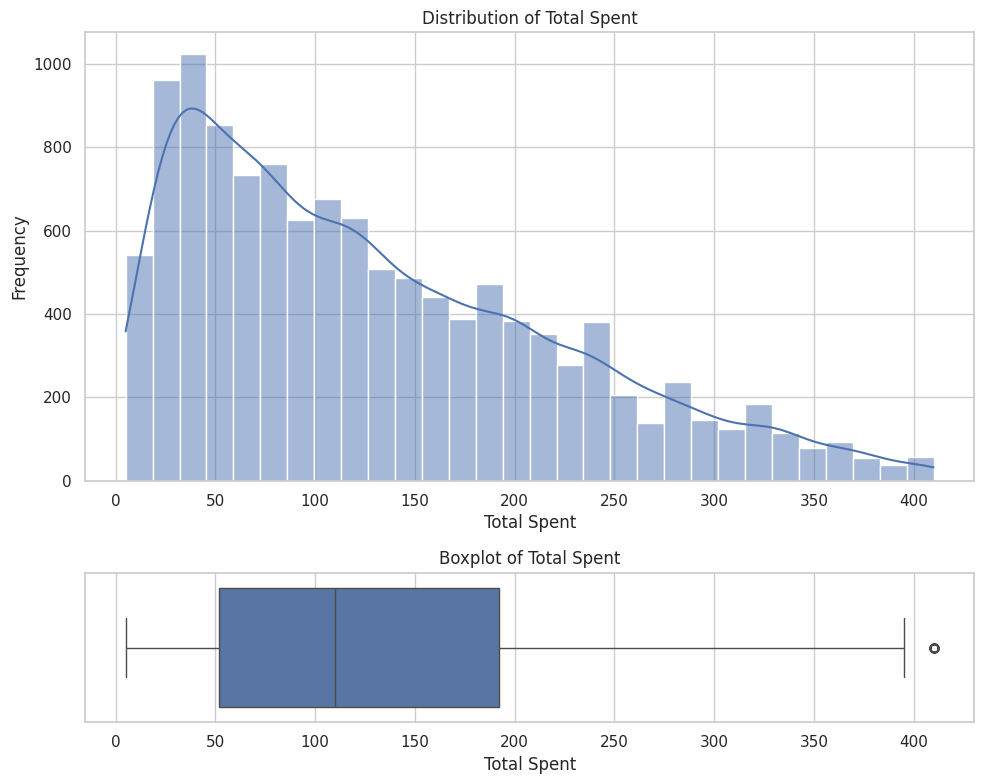

In [13]:
# Histogram with KDE and Boxplot for Total Spent

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [3, 1]})

sns.histplot(clean_df["Total Spent"], kde=True, bins=30, ax=axes[0])
axes[0].set_title("Distribution of Total Spent")
axes[0].set_xlabel("Total Spent")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=clean_df["Total Spent"], ax=axes[1])
axes[1].set_title("Boxplot of Total Spent")
axes[1].set_xlabel("Total Spent")

plt.tight_layout()
plt.show()


Observation:

The histogram shows how customer spending is distributed.
The KDE line helps show the overall spending pattern.
The boxplot shows the spread of Total Spent and helps identify possible outliers.

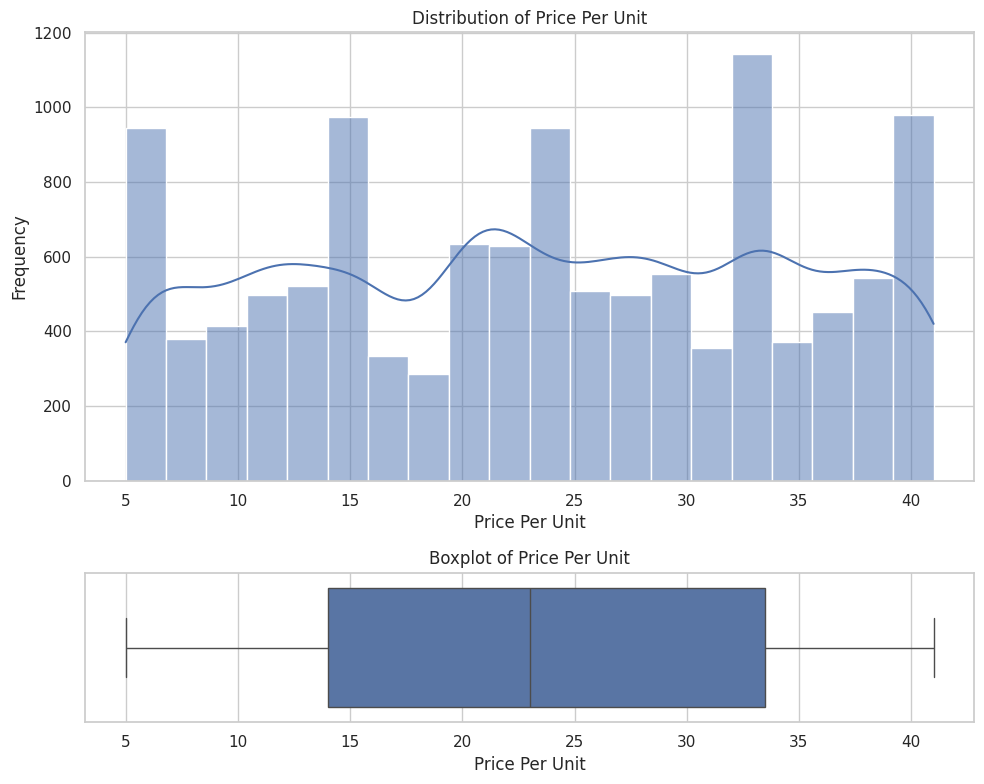

In [14]:
# Histogram with KDE and Boxplot for Price Per Unit

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [3, 1]})

sns.histplot(clean_df["Price Per Unit"], kde=True, bins=20, ax=axes[0])
axes[0].set_title("Distribution of Price Per Unit")
axes[0].set_xlabel("Price Per Unit")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=clean_df["Price Per Unit"], ax=axes[1])
axes[1].set_title("Boxplot of Price Per Unit")
axes[1].set_xlabel("Price Per Unit")

plt.tight_layout()
plt.show()

Observation:

This plot shows the distribution of item prices.
The boxplot helps identify whether some items have much higher unit prices than others.

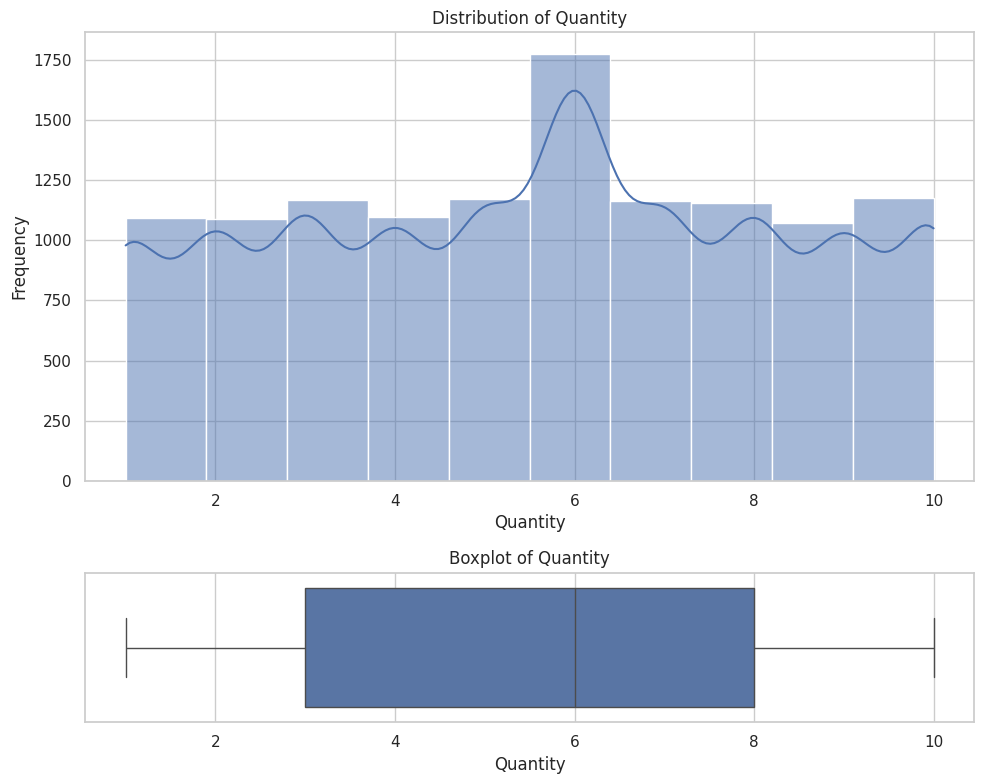

In [15]:
# Histogram with KDE and Boxplot for Quantity

fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [3, 1]})

sns.histplot(clean_df["Quantity"], kde=True, bins=10, ax=axes[0])
axes[0].set_title("Distribution of Quantity")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=clean_df["Quantity"], ax=axes[1])
axes[1].set_title("Boxplot of Quantity")
axes[1].set_xlabel("Quantity")

plt.tight_layout()
plt.show()

Observation:

Most customers purchase small quantities of items.
The boxplot shows the spread of quantity values and possible outliers.

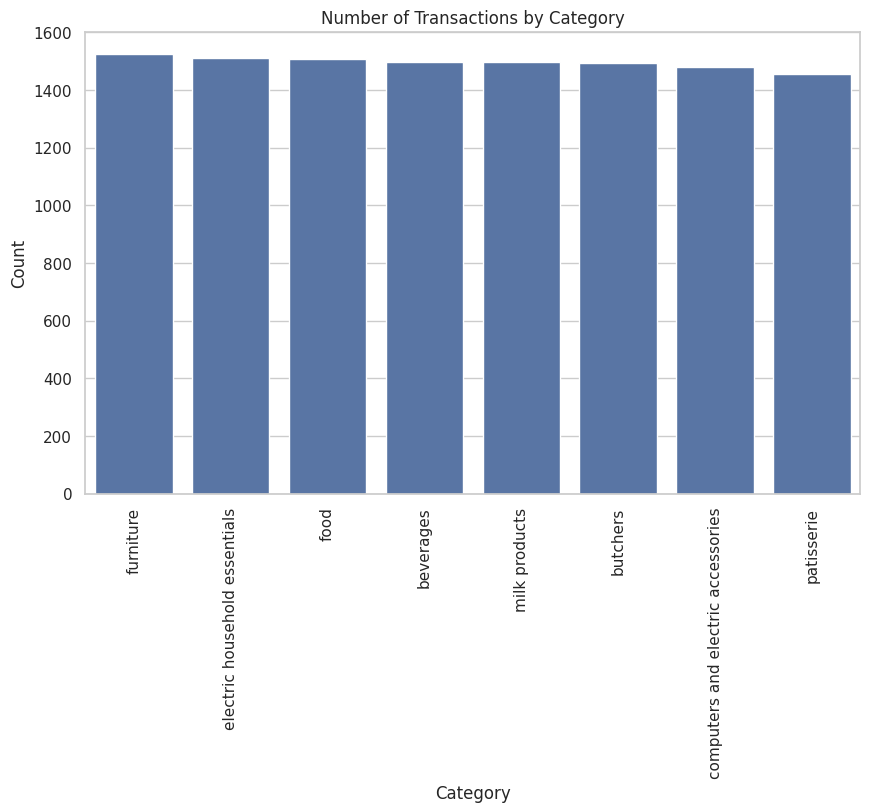

In [16]:
# Countplot for Category

plt.figure(figsize=(10,6))

sns.countplot(data=clean_df, x="Category", order=clean_df["Category"].value_counts().index)

plt.title("Number of Transactions by Category")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=90)
plt.show()

Observation:

This bar chart shows the number of transactions in each product category.
Some categories are more popular and have higher transaction counts.

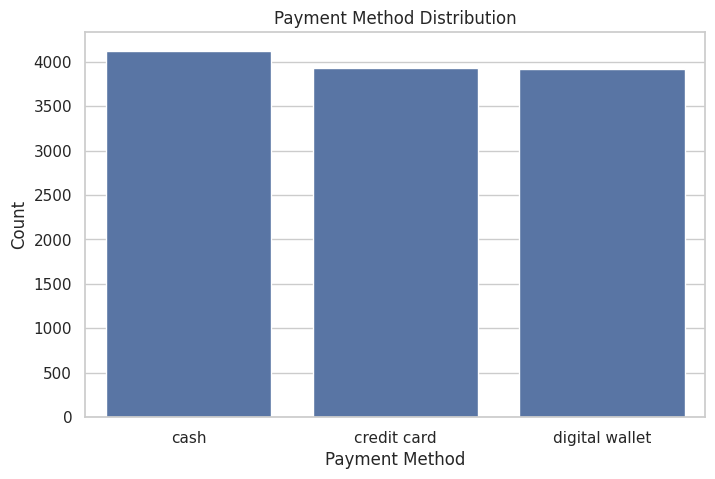

In [17]:
# Countplot for Payment Method

plt.figure(figsize=(8,5))

sns.countplot(data=clean_df, x="Payment Method",
              order=clean_df["Payment Method"].value_counts().index)

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Count")

plt.show()

Observation:

This chart shows the most commonly used payment methods.
It helps identify customer payment preferences.

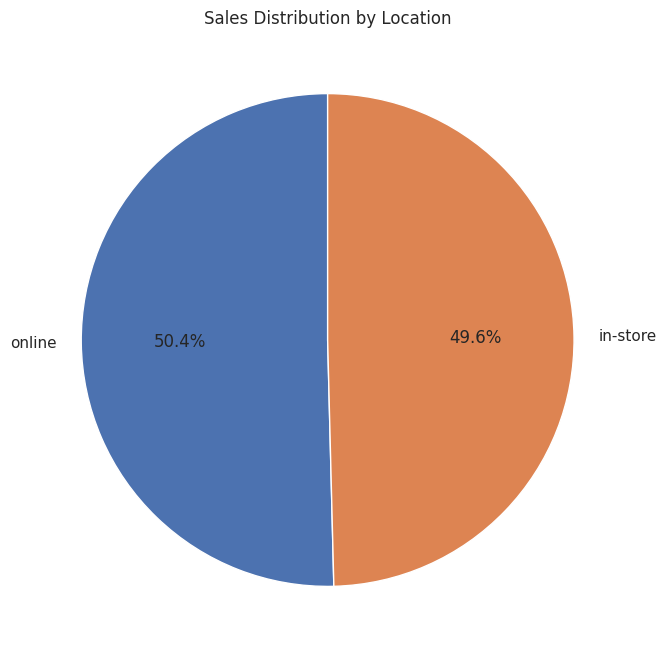

In [18]:
# Pie chart for Location distribution

location_counts = clean_df["Location"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(location_counts,
        labels=location_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Sales Distribution by Location")

plt.show()

Observation:

This pie chart shows the percentage of transactions by location.
Some locations contribute more sales than others.

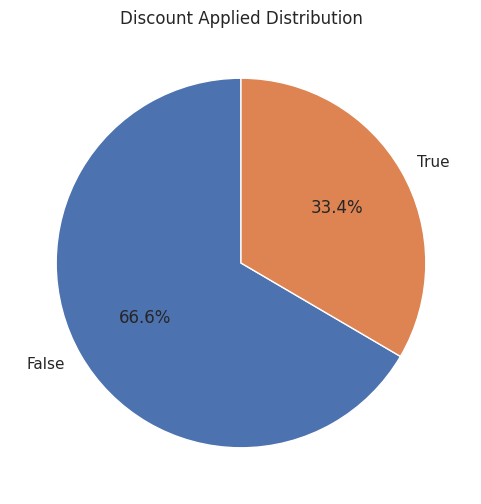

In [19]:
# Pie chart for Discount Applied

discount_counts = clean_df["Discount Applied"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(discount_counts,
        labels=discount_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Discount Applied Distribution")

plt.show()

Observation:

This chart shows the proportion of transactions with and without discounts.
Most transactions may occur without discounts depending on customer behavior.

####Bivariate Analysis


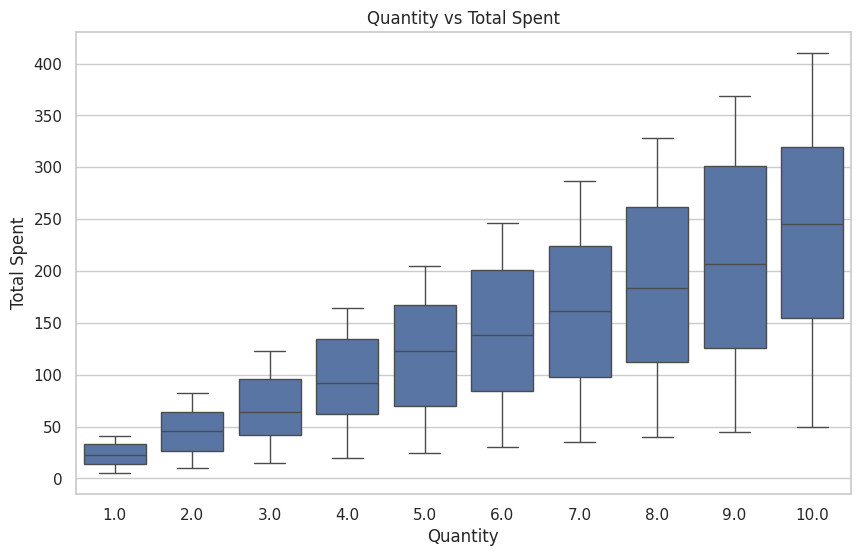

In [20]:
# Boxplot: Quantity vs Total Spent

plt.figure(figsize=(10,6))

sns.boxplot(data=clean_df,
            x="Quantity",
            y="Total Spent")

plt.title("Quantity vs Total Spent")
plt.xlabel("Quantity")
plt.ylabel("Total Spent")

plt.show()

Observation:

This boxplot compares the distribution of Total Spent across different quantity levels.
Customers who purchase higher quantities generally have higher total spending.
The plot also helps identify spending variation and possible outliers for each quantity group.

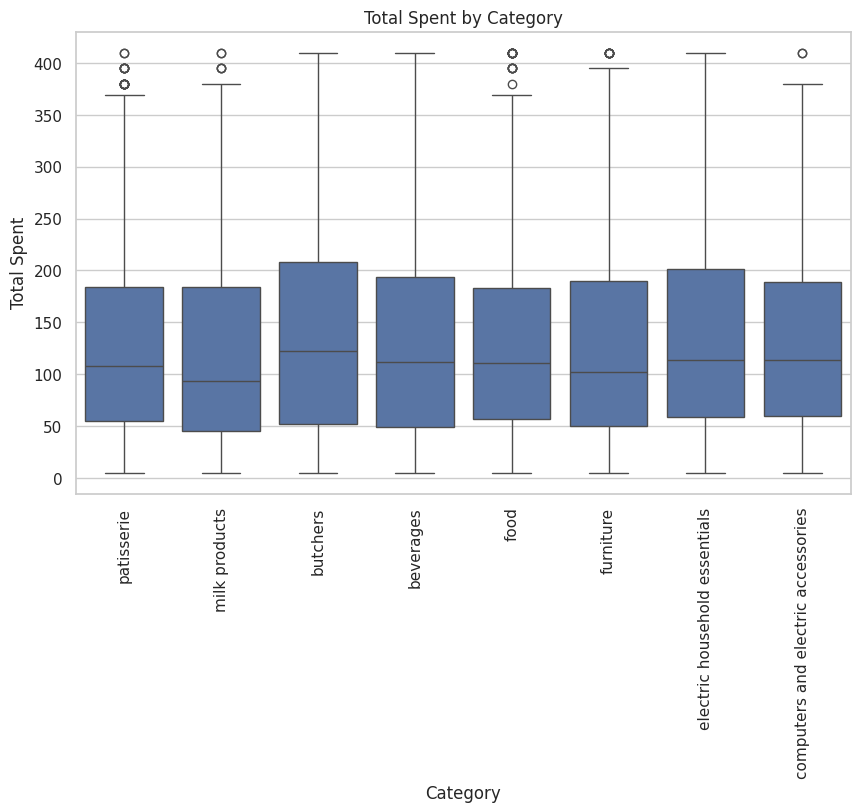

In [21]:
# Boxplot for Total Spent by Category

plt.figure(figsize=(10,6))

sns.boxplot(data=clean_df,
            x="Category",
            y="Total Spent")

plt.title("Total Spent by Category")
plt.xlabel("Category")
plt.ylabel("Total Spent")

plt.xticks(rotation=90)

plt.show()

Observation:

This boxplot compares customer spending across categories.
Some categories have higher median spending and wider spending ranges.

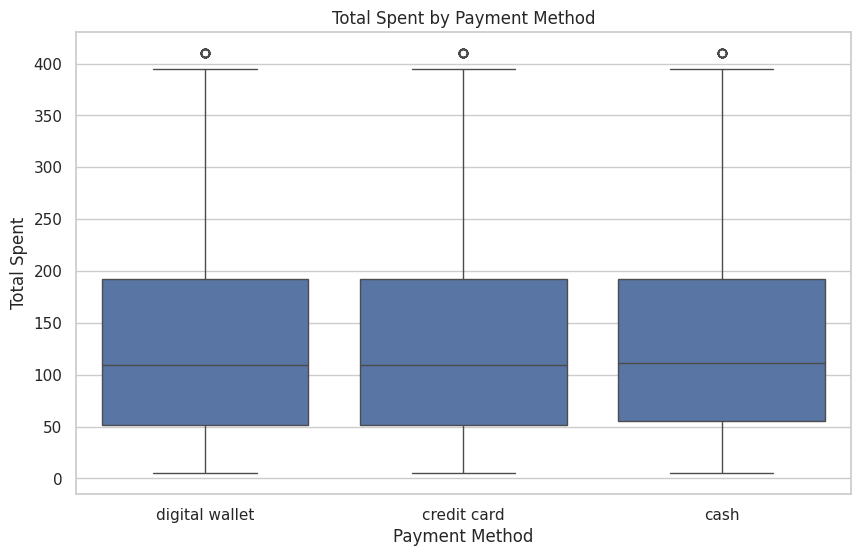

In [22]:
# Boxplot: Total Spent by Payment Method

plt.figure(figsize=(10,6))

sns.boxplot(data=clean_df,
            x="Payment Method",
            y="Total Spent")

plt.title("Total Spent by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Spent")

plt.show()

Observation:

This boxplot compares customer spending across different payment methods.
It shows the median spending, spread of values, and possible outliers for each payment type.
Some payment methods may have higher average customer spending than others.

####Multivariate Analysis


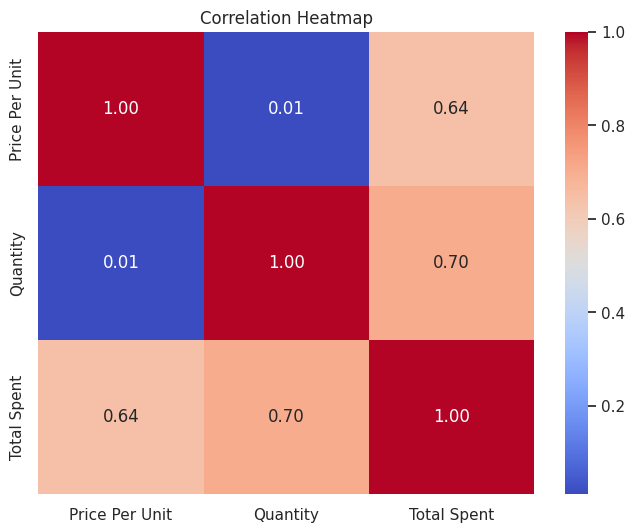

In [23]:
# Correlation heatmap

plt.figure(figsize=(8,6))


numeric_df = clean_df.select_dtypes(include=["int64", "float64"])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

Observation:

The heatmap shows relationships between numerical variables.
Total Spent has a strong positive correlation with Quantity and Price Per Unit.

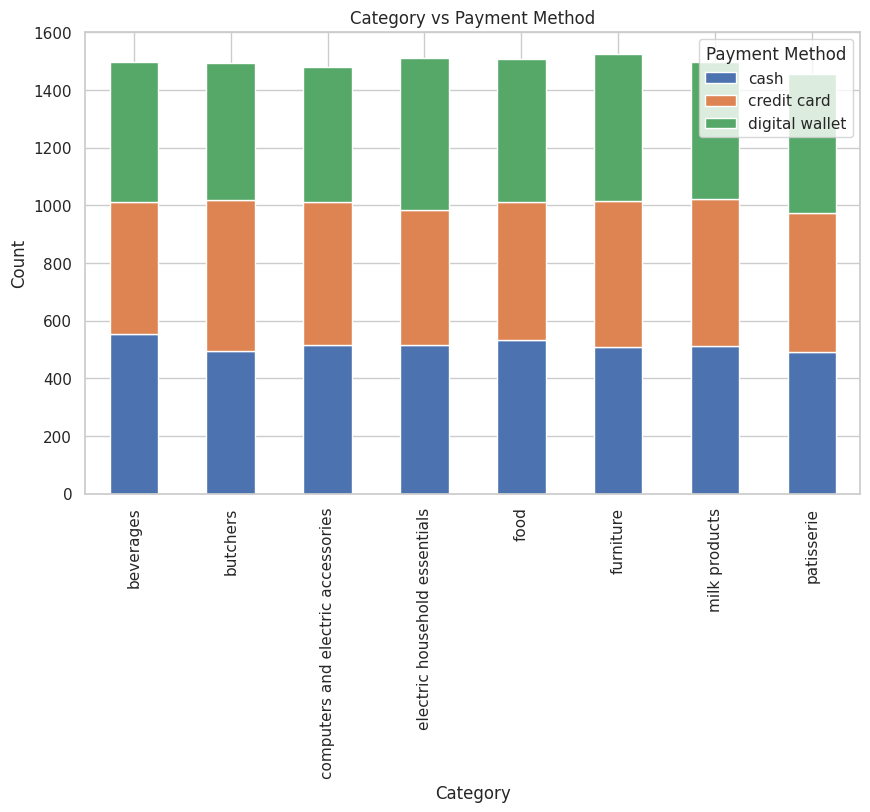

In [24]:
# Stacked bar chart for Category and Payment Method

cross_tab = pd.crosstab(clean_df["Category"],
                        clean_df["Payment Method"])

cross_tab.plot(kind="bar",
               stacked=True,
               figsize=(10,6))

plt.title("Category vs Payment Method")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

Observation:

This stacked bar chart shows the relationship between product categories and payment methods.
It helps identify preferred payment methods for different categories.

###Feature Engineering


In [25]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

# Feature 1: Transaction Month
clean_df["Transaction Month"] = clean_df["Transaction Date"].dt.month

# Feature 2: Spending Category Target
clean_df["Spending Category"] = pd.cut(
    clean_df["Total Spent"],
    bins=[-1, 50, 150, 500],
    labels=["Low", "Medium", "High"]
)

# Check new features
clean_df[["Transaction Date", "Transaction Month", "Total Spent", "Spending Category"]].head()

,Transaction Date,Transaction Month,Total Spent,Spending Category
0,2024-04-08,4,185.0,High
1,2023-07-23,7,261.0,High
2,2022-10-05,10,43.0,Low
3,2022-05-07,5,247.5,High
4,2022-10-02,10,87.5,Medium


In [26]:
# Check target distribution
clean_df["Spending Category"].value_counts()

,count
Spending Category,
Medium,4749
High,4343
Low,2874


In [27]:
# Check missing values after feature engineering
clean_df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Category,0
Item,0
Price Per Unit,0
Quantity,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0


In [28]:
# ==========================================================
# IMPORT LIBRARIES FOR MODELING
# ==========================================================

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

##Predictive Modeling and Performance Evaluation

###Prepare Data for Modeling

In [29]:
# ==========================================================
# PREPARE DATA FOR MODELING
# ==========================================================

model_df = clean_df.copy()

# Remove rows where target is missing
model_df = model_df.dropna(subset=["Spending Category"])

# Define X and y
X = model_df.drop(
    columns=[
        "Spending Category",
        "Transaction ID",
        "Customer ID",
        "Transaction Date",
        "Total Spent"
    ],
    errors="ignore"
)

y = model_df["Spending Category"]

# Convert categorical columns into numeric dummy variables
X = pd.get_dummies(X, drop_first=True)

print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Feature shape: (11966, 213)
Target distribution:
Spending Category
Medium    4749
High      4343
Low       2874
Name: count, dtype: int64


###Train-Test Split

In [30]:
# ==========================================================
# TRAIN-TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape of training set:", X_train.shape)
print("Shape of testing set:", X_test.shape)

print("\nPercentage of classes in training set:")
print(y_train.value_counts(normalize=True).round(2))

print("\nPercentage of classes in testing set:")
print(y_test.value_counts(normalize=True).round(2))

Shape of training set: (9572, 213)
Shape of testing set: (2394, 213)

Percentage of classes in training set:
Spending Category
Medium    0.40
High      0.36
Low       0.24
Name: proportion, dtype: float64

Percentage of classes in testing set:
Spending Category
Medium    0.40
High      0.36
Low       0.24
Name: proportion, dtype: float64


###Scaling

In [31]:
# ==========================================================
# FEATURE SCALING
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

###Create Evaluation Function

In [32]:
# ==========================================================
# MODEL EVALUATION FUNCTION
# ==========================================================

def metrics_score(actual, predicted):
    print(classification_report(actual, predicted, zero_division=0))

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=sorted(actual.unique()),
        yticklabels=sorted(actual.unique())
    )

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [33]:
# Create empty list to store testing results
results = []

##Model 1: Logistic Regression Model

###Building Logistic Regression Model

In [34]:
# ==========================================================
# LOGISTIC REGRESSION MODEL
# ==========================================================

lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

###Checking Performance on Training Set

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3474
         Low       1.00      1.00      1.00      2299
      Medium       1.00      1.00      1.00      3799

    accuracy                           1.00      9572
   macro avg       1.00      1.00      1.00      9572
weighted avg       1.00      1.00      1.00      9572



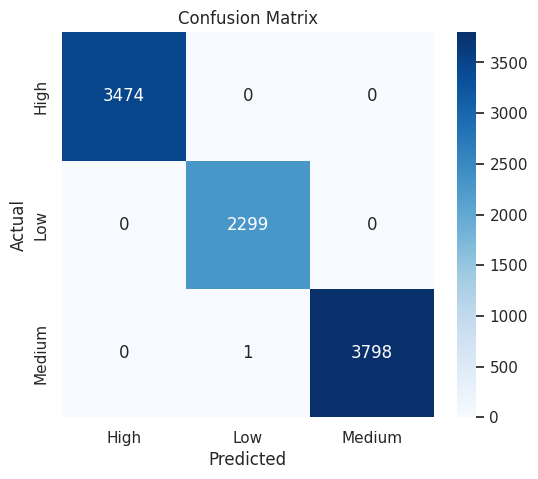

In [35]:
# Checking performance on training data
lr_train_pred = lr_model.predict(X_train_scaled)

metrics_score(y_train, lr_train_pred)

###Checking Performance on Testing Set

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       869
         Low       0.99      0.99      0.99       575
      Medium       0.99      0.99      0.99       950

    accuracy                           0.99      2394
   macro avg       0.99      0.99      0.99      2394
weighted avg       0.99      0.99      0.99      2394



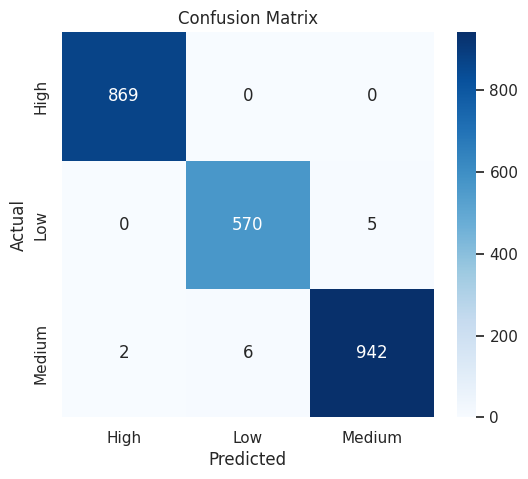

In [36]:
# Checking performance on testing data
lr_test_pred = lr_model.predict(X_test_scaled)

metrics_score(y_test, lr_test_pred)

In [37]:
# Store Logistic Regression test result
results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, lr_test_pred),
    "Precision": precision_score(y_test, lr_test_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, lr_test_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, lr_test_pred, average="weighted", zero_division=0),
    "Tuned": "No",
    "PCA": "No"
})

##Model 2:KNN Model

###Building KNN Model

In [38]:
# ==========================================================
# KNN MODEL
# ==========================================================

knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

###Checking Performance on Training Set

              precision    recall  f1-score   support

        High       0.85      0.92      0.88      3474
         Low       0.89      0.76      0.82      2299
      Medium       0.81      0.82      0.82      3799

    accuracy                           0.84      9572
   macro avg       0.85      0.83      0.84      9572
weighted avg       0.84      0.84      0.84      9572



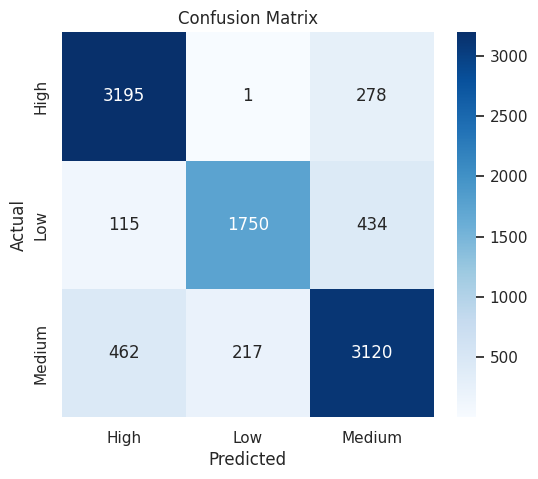

In [39]:
knn_train_pred = knn_model.predict(X_train_scaled)

metrics_score(y_train, knn_train_pred)

###Checking Performance on Testing Set

              precision    recall  f1-score   support

        High       0.76      0.87      0.81       869
         Low       0.81      0.66      0.73       575
      Medium       0.70      0.69      0.70       950

    accuracy                           0.75      2394
   macro avg       0.76      0.74      0.75      2394
weighted avg       0.75      0.75      0.75      2394



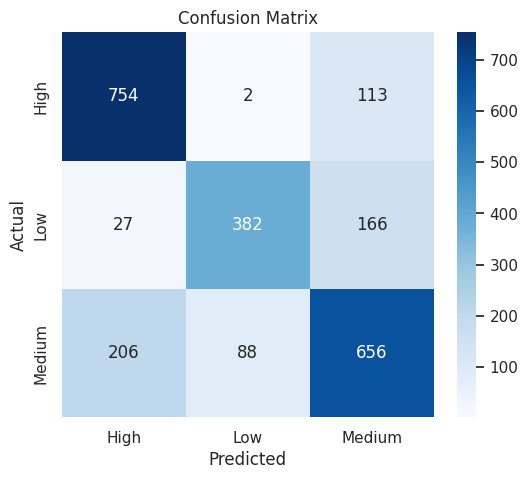

In [40]:
knn_test_pred = knn_model.predict(X_test_scaled)

metrics_score(y_test, knn_test_pred)

In [41]:
# Store KNN test result
results.append({
    "Model": "KNN",
    "Accuracy": accuracy_score(y_test, knn_test_pred),
    "Precision": precision_score(y_test, knn_test_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, knn_test_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, knn_test_pred, average="weighted", zero_division=0),
    "Tuned": "No",
    "PCA": "No"
})

##Model 3: Decision Tree Model

###Building Decision Tree Model


In [42]:
# ==========================================================
# DECISION TREE MODEL
# ==========================================================

dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

###Checking Performance on Training Set

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3474
         Low       1.00      1.00      1.00      2299
      Medium       1.00      1.00      1.00      3799

    accuracy                           1.00      9572
   macro avg       1.00      1.00      1.00      9572
weighted avg       1.00      1.00      1.00      9572



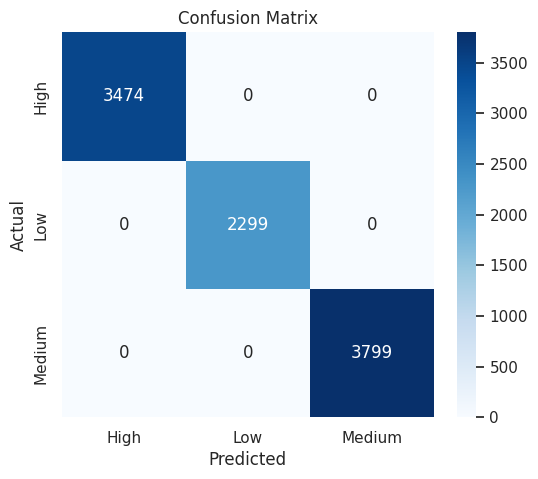

In [43]:
dt_train_pred = dt_model.predict(X_train_scaled)

metrics_score(y_train, dt_train_pred)

###Checking Performance on Testing Set

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       869
         Low       1.00      1.00      1.00       575
      Medium       1.00      1.00      1.00       950

    accuracy                           1.00      2394
   macro avg       1.00      1.00      1.00      2394
weighted avg       1.00      1.00      1.00      2394



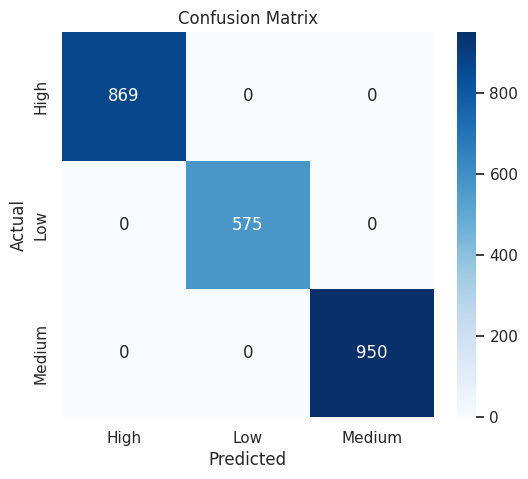

In [44]:
dt_test_pred = dt_model.predict(X_test_scaled)

metrics_score(y_test, dt_test_pred)

In [45]:
# Store Decision Tree test result
results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, dt_test_pred),
    "Precision": precision_score(y_test, dt_test_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, dt_test_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, dt_test_pred, average="weighted", zero_division=0),
    "Tuned": "No",
    "PCA": "No"
})

##Model 4: Random Forest Model

###Building Random Forest Model

In [46]:
# ==========================================================
# RANDOM FOREST MODEL
# ==========================================================

rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

###Checking Performance on Training Set

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3474
         Low       1.00      1.00      1.00      2299
      Medium       1.00      1.00      1.00      3799

    accuracy                           1.00      9572
   macro avg       1.00      1.00      1.00      9572
weighted avg       1.00      1.00      1.00      9572



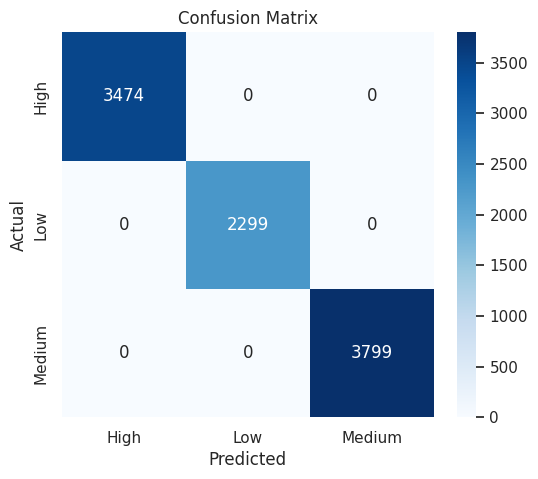

In [47]:
rf_train_pred = rf_model.predict(X_train_scaled)

metrics_score(y_train, rf_train_pred)

###Checking Performance on Testing Set

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       869
         Low       0.99      0.99      0.99       575
      Medium       0.99      1.00      0.99       950

    accuracy                           0.99      2394
   macro avg       1.00      0.99      0.99      2394
weighted avg       1.00      0.99      0.99      2394



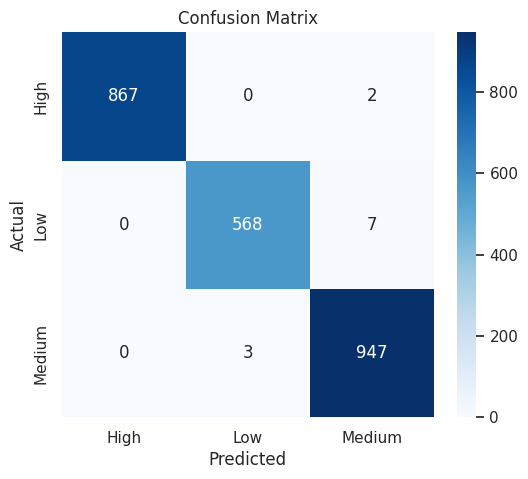

In [48]:
rf_test_pred = rf_model.predict(X_test_scaled)

metrics_score(y_test, rf_test_pred)

In [49]:
# Store Random Forest test result
results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_test_pred),
    "Precision": precision_score(y_test, rf_test_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, rf_test_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, rf_test_pred, average="weighted", zero_division=0),
    "Tuned": "No",
    "PCA": "No"
})

##Initial Model Comparison

In [50]:
# ==========================================================
# INITIAL MODEL COMPARISON
# ==========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1-Score", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,Tuned,PCA
2,Decision Tree,1.000000,1.000000,1.000000,1.000000,No,No
3,Random Forest,0.994987,0.995002,0.994987,0.994988,No,No
0,Logistic Regression,0.994570,0.994569,0.994570,0.994568,No,No
1,KNN,0.748538,0.750100,0.748538,0.746392,No,No


##Hyperparameter Tuning: Decision Tree

In [51]:
# ==========================================================
# DECISION TREE HYPERPARAMETER TUNING
# ==========================================================

param_grid_dt = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_dt.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_dt.best_params_)

print("Best CV F1-Score:")
print(grid_dt.best_score_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1-Score:
1.0


##Tuned Decision Tree Evaluation

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3474
         Low       1.00      1.00      1.00      2299
      Medium       1.00      1.00      1.00      3799

    accuracy                           1.00      9572
   macro avg       1.00      1.00      1.00      9572
weighted avg       1.00      1.00      1.00      9572



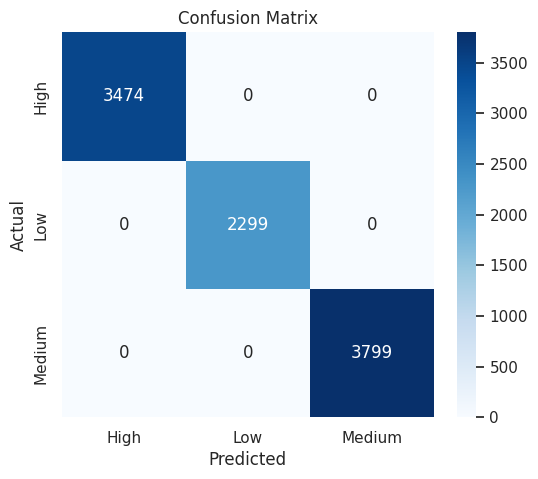

In [52]:
# Best tuned decision tree model
dt_tuned = grid_dt.best_estimator_

# Training performance
dt_tuned_train_pred = dt_tuned.predict(X_train_scaled)

metrics_score(y_train, dt_tuned_train_pred)

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       869
         Low       1.00      1.00      1.00       575
      Medium       1.00      1.00      1.00       950

    accuracy                           1.00      2394
   macro avg       1.00      1.00      1.00      2394
weighted avg       1.00      1.00      1.00      2394



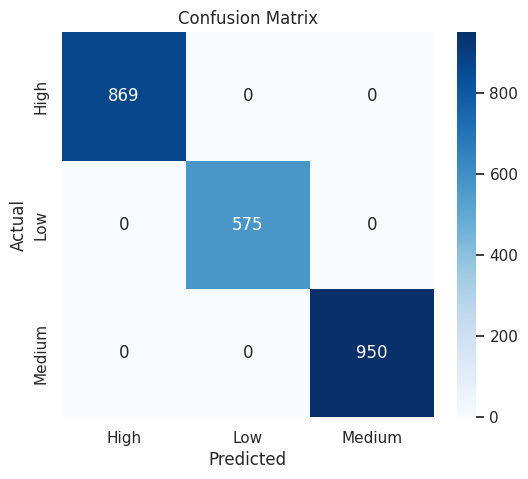

In [53]:
# Testing performance
dt_tuned_test_pred = dt_tuned.predict(X_test_scaled)

metrics_score(y_test, dt_tuned_test_pred)

In [54]:
# Store tuned Decision Tree result
tuned_dt_result = {
    "Model": "Tuned Decision Tree",
    "Accuracy": accuracy_score(y_test, dt_tuned_test_pred),
    "Precision": precision_score(y_test, dt_tuned_test_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, dt_tuned_test_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, dt_tuned_test_pred, average="weighted", zero_division=0),
    "Tuned": "Yes",
    "PCA": "No"
}

tuned_dt_result

{'Model': 'Tuned Decision Tree',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1-Score': 1.0,
 'Tuned': 'Yes',
 'PCA': 'No'}

##Feature Importance

In [55]:
# ==========================================================
# FEATURE IMPORTANCE - TUNED DECISION TREE
# ==========================================================

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_tuned.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
0,Price Per Unit,0.561832
1,Quantity,0.433044
155,Item_item_3_but,0.005124
3,Transaction Month,0.000000
2,Discount Applied,0.000000
5,Category_computers and electric accessories,0.000000
6,Category_electric household essentials,0.000000
7,Category_food,0.000000
8,Category_furniture,0.000000
9,Category_milk products,0.000000


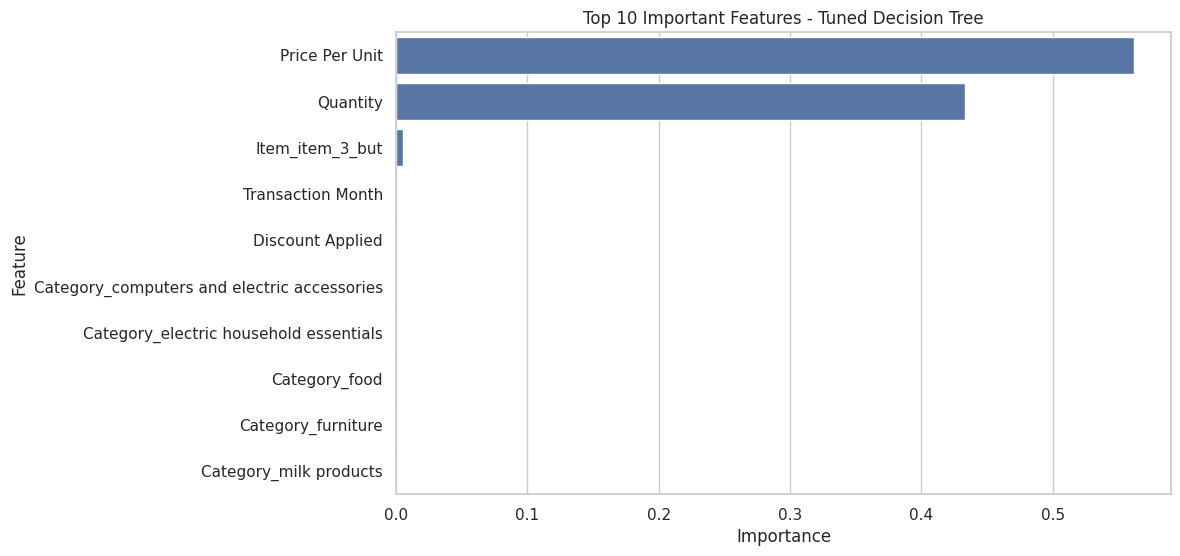

In [56]:
# Plot feature importance

top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Tuned Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

##Visualizing the Decision Tree

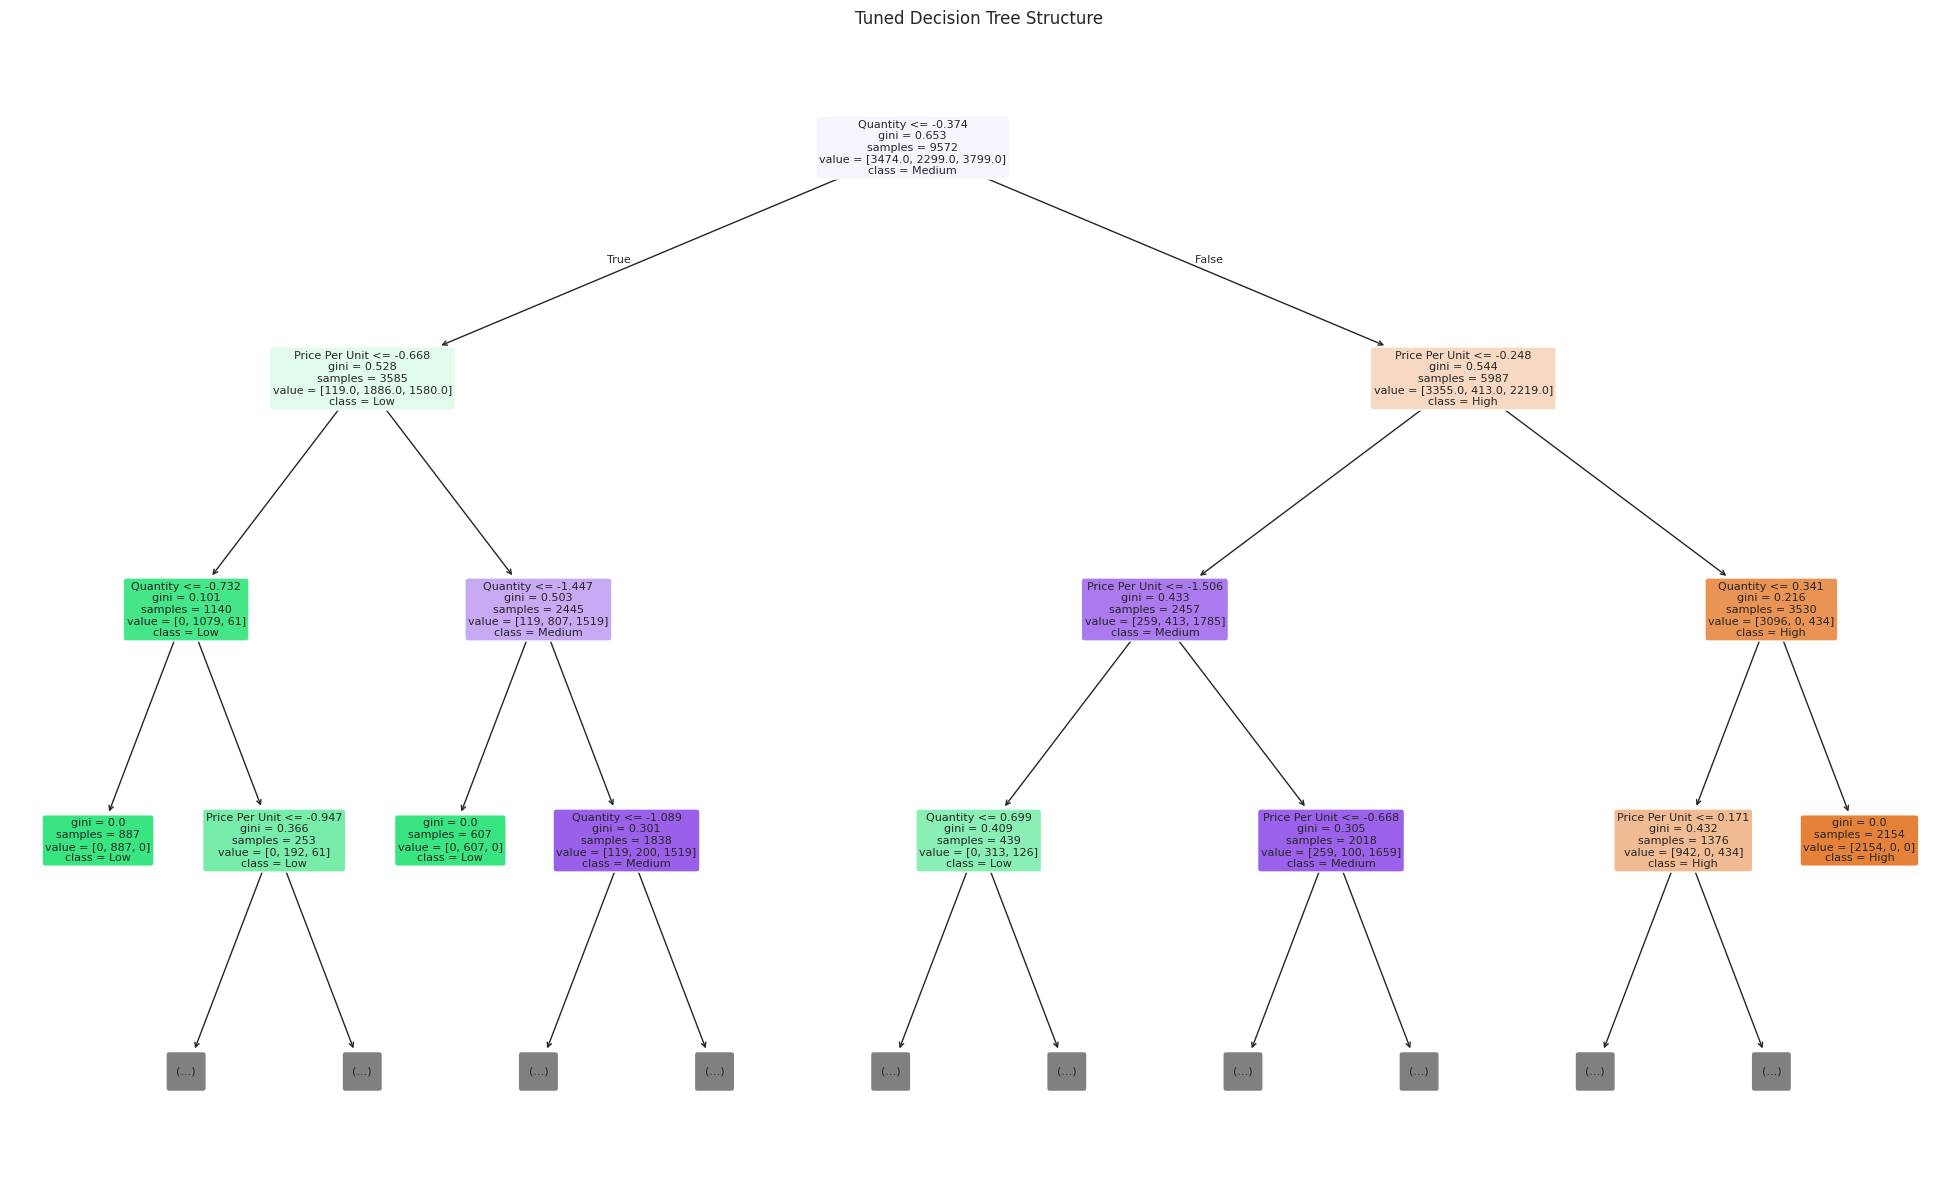

In [57]:
# ==========================================================
# VISUALIZING THE TUNED DECISION TREE
# ==========================================================

plt.figure(figsize=(25, 15))

plot_tree(
    dt_tuned,
    feature_names=X.columns,
    class_names=dt_tuned.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)

plt.title("Tuned Decision Tree Structure")
plt.show()

##PCA Dimensionality Reduction

In [58]:
# ==========================================================
# PCA DIMENSIONALITY REDUCTION
# ==========================================================

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])

Original number of features: 213
Number of PCA components: 193


##PCA Model Training

In [59]:
# ==========================================================
# PCA MODEL TRAINING - DECISION TREE
# ==========================================================

pca_dt_model = DecisionTreeClassifier(
    random_state=42,
    **grid_dt.best_params_
)

pca_dt_model.fit(X_train_pca, y_train)

DecisionTreeClassifier(max_depth=10, random_state=42)

              precision    recall  f1-score   support

        High       0.95      0.93      0.94      3474
         Low       0.96      0.85      0.90      2299
      Medium       0.86      0.93      0.90      3799

    accuracy                           0.91      9572
   macro avg       0.92      0.91      0.91      9572
weighted avg       0.92      0.91      0.91      9572



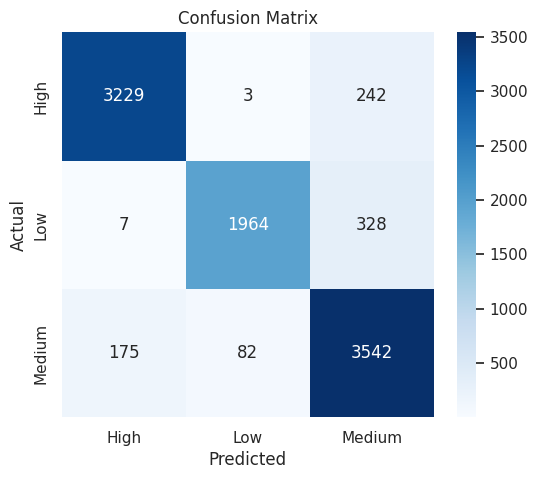

In [60]:
# PCA model training performance
pca_dt_train_pred = pca_dt_model.predict(X_train_pca)

metrics_score(y_train, pca_dt_train_pred)

              precision    recall  f1-score   support

        High       0.88      0.87      0.88       869
         Low       0.85      0.73      0.78       575
      Medium       0.75      0.83      0.79       950

    accuracy                           0.82      2394
   macro avg       0.83      0.81      0.82      2394
weighted avg       0.82      0.82      0.82      2394



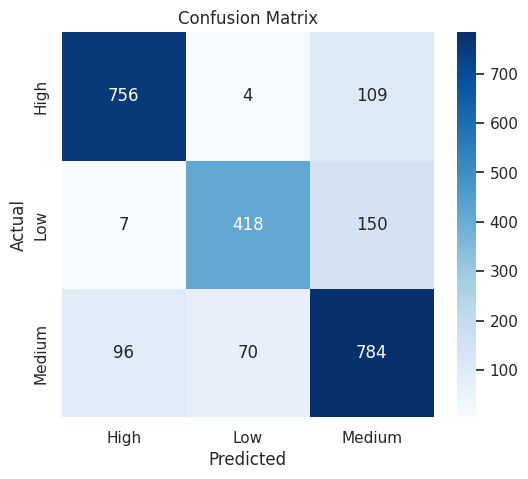

In [61]:
# PCA model testing performance
pca_dt_test_pred = pca_dt_model.predict(X_test_pca)

metrics_score(y_test, pca_dt_test_pred)

In [62]:
# Store PCA model result
pca_dt_result = {
    "Model": "PCA Decision Tree",
    "Accuracy": accuracy_score(y_test, pca_dt_test_pred),
    "Precision": precision_score(y_test, pca_dt_test_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, pca_dt_test_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, pca_dt_test_pred, average="weighted", zero_division=0),
    "Tuned": "Yes",
    "PCA": "Yes"
}

pca_dt_result

{'Model': 'PCA Decision Tree',
 'Accuracy': 0.8178780284043442,
 'Precision': 0.8218091692604964,
 'Recall': 0.8178780284043442,
 'F1-Score': 0.8180060232928089,
 'Tuned': 'Yes',
 'PCA': 'Yes'}

##Final Model Comparison

In [63]:
# ==========================================================
# FINAL MODEL COMPARISON
# ==========================================================

final_results = pd.concat([
    results_df,
    pd.DataFrame([tuned_dt_result]),
    pd.DataFrame([pca_dt_result])
], ignore_index=True)

final_results = final_results.sort_values(by="F1-Score", ascending=False)

final_results

,Model,Accuracy,Precision,Recall,F1-Score,Tuned,PCA
0,Decision Tree,1.000000,1.000000,1.000000,1.000000,No,No
4,Tuned Decision Tree,1.000000,1.000000,1.000000,1.000000,Yes,No
1,Random Forest,0.994987,0.995002,0.994987,0.994988,No,No
2,Logistic Regression,0.994570,0.994569,0.994570,0.994568,No,No
5,PCA Decision Tree,0.817878,0.821809,0.817878,0.818006,Yes,Yes
3,KNN,0.748538,0.750100,0.748538,0.746392,No,No


##Model Performance Visualization

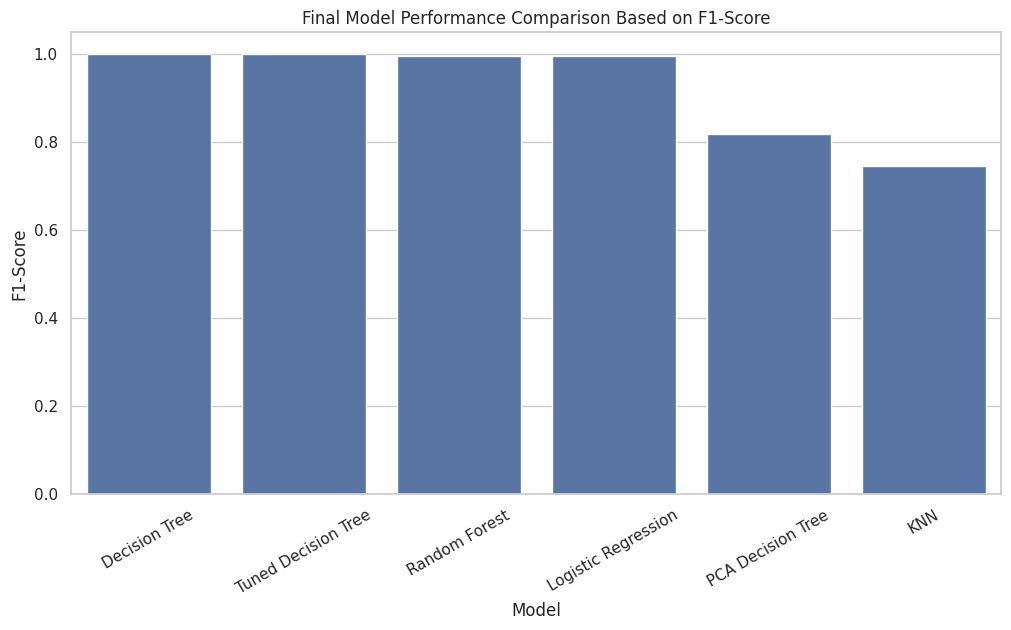

In [65]:
# ==========================================================
# MODEL PERFORMANCE VISUALIZATION
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=final_results,
    x="Model",
    y="F1-Score"
)

plt.title("Final Model Performance Comparison Based on F1-Score")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=30)

plt.show()

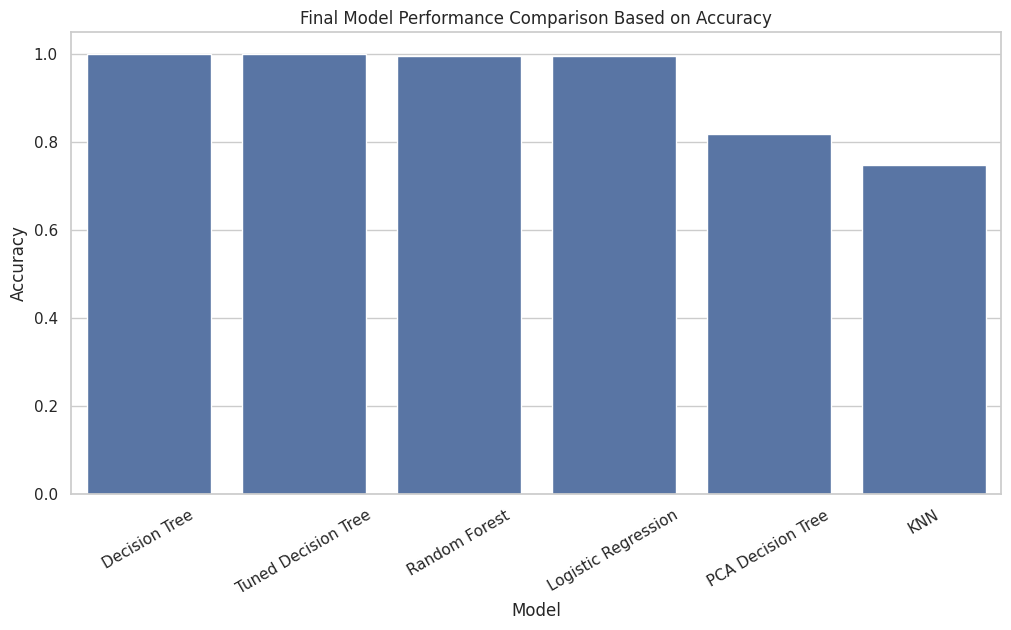

In [66]:
# Accuracy comparison chart

plt.figure(figsize=(12,6))

sns.barplot(
    data=final_results,
    x="Model",
    y="Accuracy"
)

plt.title("Final Model Performance Comparison Based on Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

plt.show()

##Confusion Matrix for Best Model

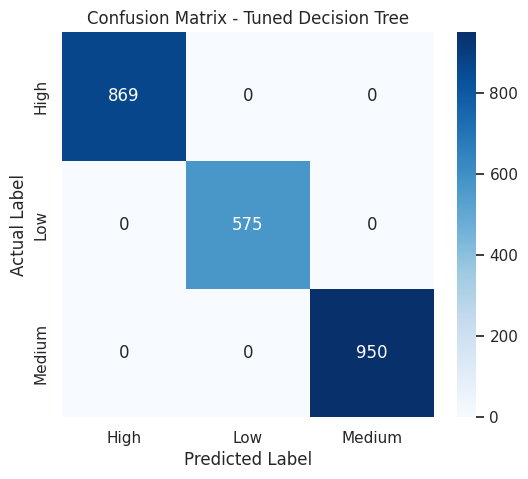

In [67]:
# ==========================================================
# CONFUSION MATRIX FOR BEST MODEL
# ==========================================================

cm = confusion_matrix(y_test, dt_tuned_test_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dt_tuned.classes_,
    yticklabels=dt_tuned.classes_
)

plt.title("Confusion Matrix - Tuned Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

##Feature Insight Visualization

In [74]:
# ==========================================================
# FEATURE INSIGHT VISUALIZATION
# ==========================================================

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_tuned.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(10)

,Feature,Importance
0,Price Per Unit,0.561832
1,Quantity,0.433044
155,Item_item_3_but,0.005124
3,Transaction Month,0.000000
2,Discount Applied,0.000000
5,Category_computers and electric accessories,0.000000
6,Category_electric household essentials,0.000000
7,Category_food,0.000000
8,Category_furniture,0.000000
9,Category_milk products,0.000000


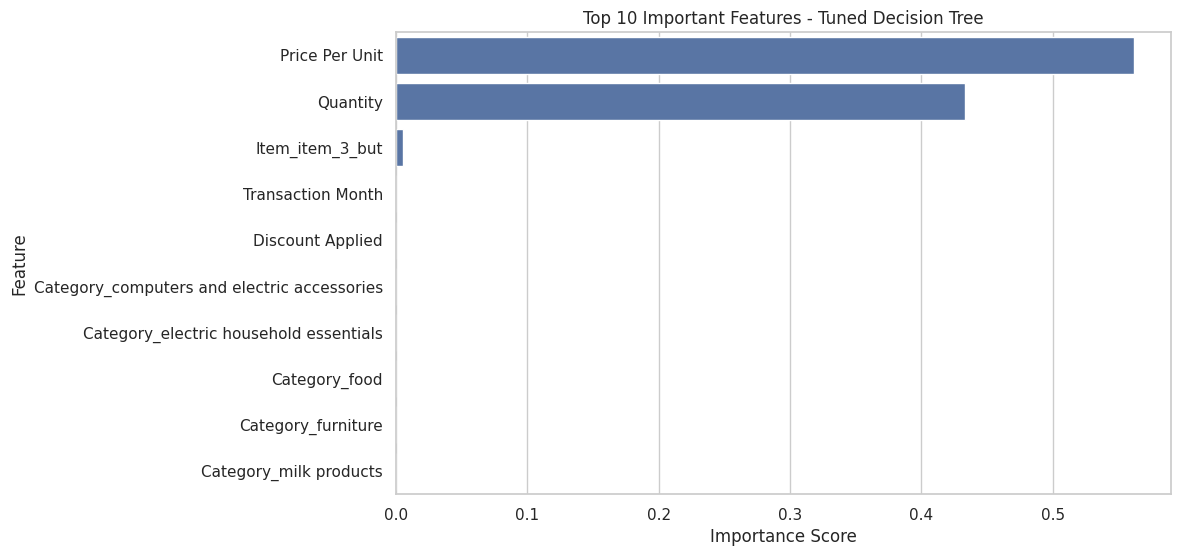

In [75]:
# Plot feature importance

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Tuned Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

##Key Business Insight Visualization

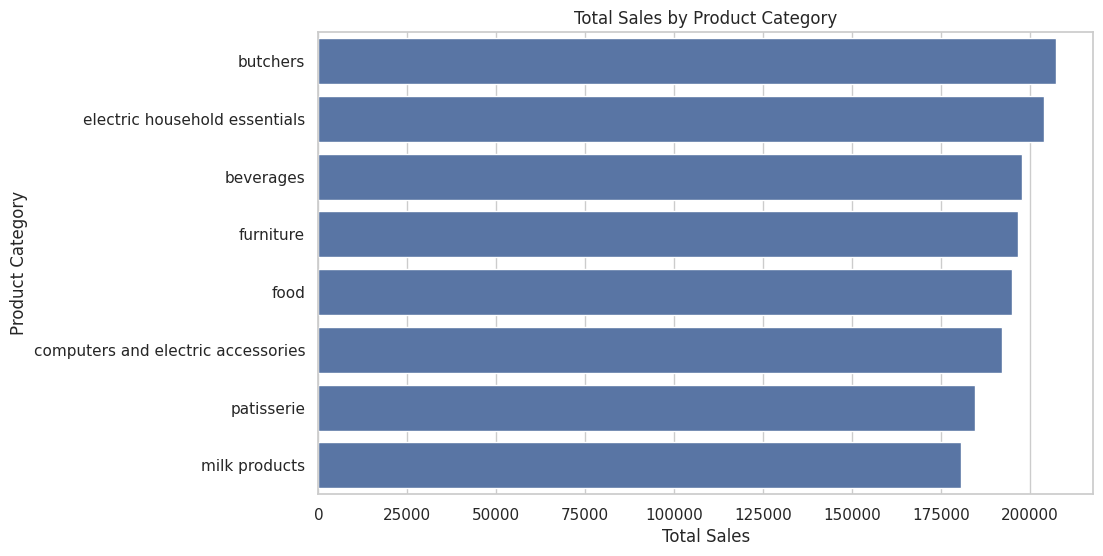

In [70]:
# ==========================================================
# KEY BUSINESS INSIGHT VISUALIZATION
# ==========================================================

category_sales = clean_df.groupby("Category")["Total Spent"].sum()
category_sales = category_sales.sort_values(ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Total Sales by Product Category")
plt.xlabel("Total Sales")
plt.ylabel("Product Category")

plt.show()

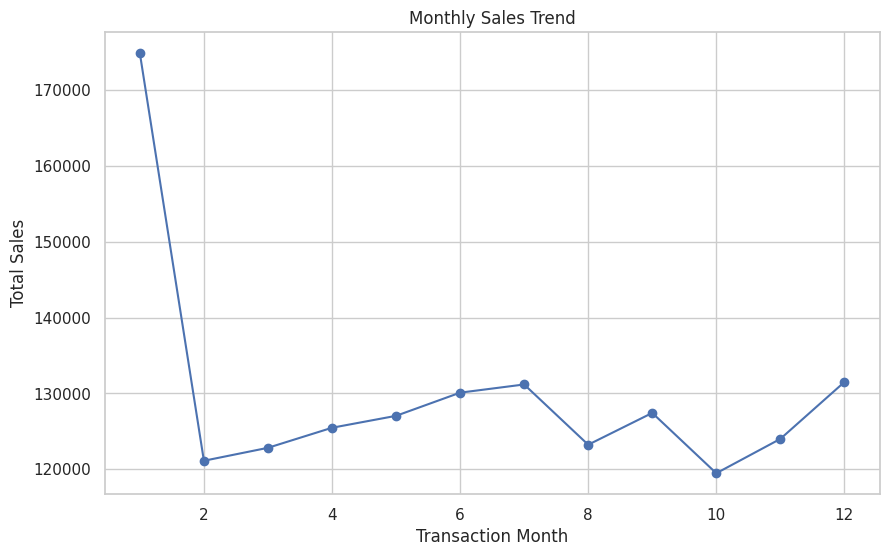

In [71]:
# Monthly sales trend

monthly_sales = clean_df.groupby("Transaction Month")["Total Spent"].sum()

plt.figure(figsize=(10,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Transaction Month")
plt.ylabel("Total Sales")

plt.show()